# СберАвтоподписка - анализ сайта и предсказание целевого действия

**Задача:** создать модель, которая предсказывает вероятность того, что пользователь совершит целевое действие (оставит заявку, закажет звонок и пр.) на сайте.

**Структура ноутбука:**
1. Загрузка данных
2. EDA: чистка, типизация, пропуски
3. Распределения и CR в разрезах
4. Фиче-инжиниринг и корреляционная карта
5. Обучение моделей
6. Интерпретация фичей (importance, SHAP)
7. Выводы и сохранение модели

In [2]:
import sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT.parent

from api.preprocessing import clean_sessions
from target_actions import TARGET_ACTIONS
print('TARGET_ACTIONS:', TARGET_ACTIONS)

TARGET_ACTIONS: ['sub_car_claim_click', 'sub_car_claim_submit_click', 'sub_open_dialog_click', 'sub_custom_question_submit_click', 'sub_call_number_click', 'sub_callback_submit_click', 'sub_submit_success', 'sub_car_request_submit_click']


## 1. Загрузка данных

In [3]:
sessions = pd.read_pickle(DATA_DIR / 'ga_sessions.pkl')
print('sessions:', sessions.shape)

# 15.7M строк в память целиком не помещаются, 
# поэтому будем читать CSV чанками и сразу фильтровать по целевым event_action, 
# накапливая set целевых session_id.
def load_target_session_ids() -> set:
    target = set()
    targets_set = set(TARGET_ACTIONS)
    n = 0
    for chunk in pd.read_csv(DATA_DIR / 'ga_hits.csv',
                             usecols=['session_id', 'event_action'],
                             chunksize=2_000_000, low_memory=False):
        m = chunk['event_action'].isin(targets_set)
        target.update(chunk.loc[m, 'session_id'].unique())
        n += len(chunk)
        print(f'  read {n:,} rows')
    return target

target_session_ids = load_target_session_ids()
print('target sessions:', len(target_session_ids))
sessions.head(3)

sessions: (1860042, 18)
  read 2,000,000 rows
  read 4,000,000 rows
  read 6,000,000 rows
  read 8,000,000 rows
  read 10,000,000 rows
  read 12,000,000 rows
  read 14,000,000 rows
  read 15,726,470 rows
target sessions: 50760


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk


In [4]:
print('Типы данных:'); print(sessions.dtypes)
print('\nОсновная информация:'); sessions.info(memory_usage='deep')

Типы данных:
session_id                  object
client_id                   object
visit_date                  object
visit_time                  object
visit_number                 int64
utm_source                  object
utm_medium                  object
utm_campaign                object
utm_adcontent               object
utm_keyword                 object
device_category             object
device_os                   object
device_brand                object
device_model                object
device_screen_resolution    object
device_browser              object
geo_country                 object
geo_city                    object
dtype: object

Основная информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time   

## 2. EDA: чистка, типизация, пропуски

Логика дедупликации, приведения типов и обработки NaN находится в `clean_sessions` из `api/preprocessing.py`, чтобы EDA, train.py и API смотрели на одни и те же данные.

In [5]:
# 2.1 Дубликаты
n_dup = sessions.duplicated(subset='session_id').sum()
print(f'дубликатов session_id: {n_dup} ({n_dup/len(sessions):.4%})')

дубликатов session_id: 0 (0.0000%)


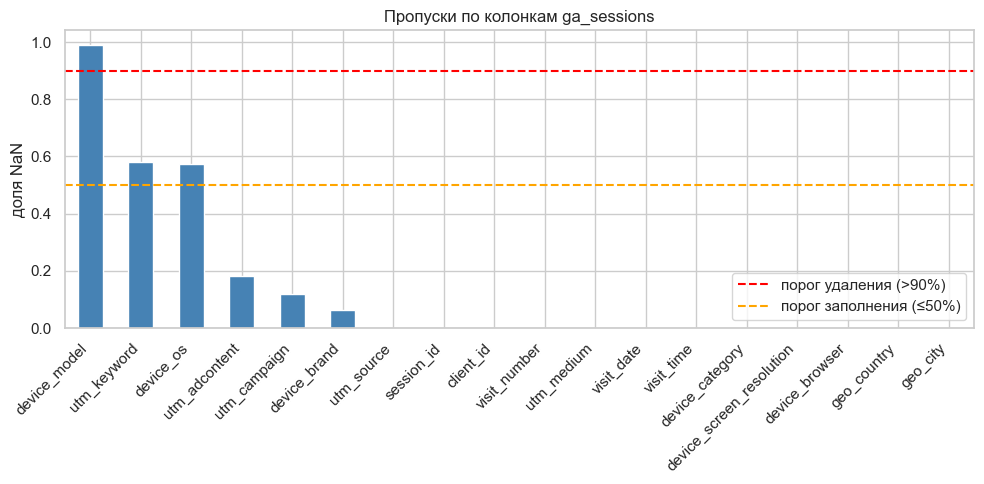

device_model     0.991216
utm_keyword      0.581740
device_os        0.575330
utm_adcontent    0.180434
utm_campaign     0.118063
device_brand     0.063804
utm_source       0.000052
dtype: float64

In [6]:
# 2.2 Пропуски - bar-chart по доле NaN
nan_share = sessions.isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
nan_share.plot.bar(ax=ax, color='steelblue')
ax.axhline(0.9, color='red', linestyle='--', label='порог удаления (>90%)')
ax.axhline(0.5, color='orange', linestyle='--', label='порог заполнения (≤50%)')
ax.set_ylabel('доля NaN'); ax.set_title('Пропуски по колонкам ga_sessions'); ax.legend()
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
nan_share[nan_share > 0]

**Решение по пропускам:**   
колонки с долей NaN > 90% удаляются  
колонки с долей NaN ≤ 90% - заполняются ('unknown' для категорий, медиана для чисел). Эта логика инкапсулирована в `clean_sessions`.

In [7]:
# 2.3 Применяем clean_sessions
sessions_clean = clean_sessions(sessions, verbose=True)
print('NaN после чистки:', int(sessions_clean.isna().sum().sum()))
sessions_clean.head(3)

after dedup: shape=(1860042, 18)
dropped (NaN > 90%): ['device_model']
clean_sessions done: shape=(1860042, 17), NaN total=0
NaN после чистки: 0


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk


## 3. Распределения и CR в разрезах

`target = 1`, если в ga_hits для session_id есть хотя бы один хит с event_action из TARGET_ACTIONS

In [8]:
y = sessions_clean['session_id'].isin(target_session_ids).astype(int)
print(f'positives: {int(y.sum())} / {len(y)}  CR = {y.mean():.4%}')

positives: 50314 / 1860042  CR = 2.7050%


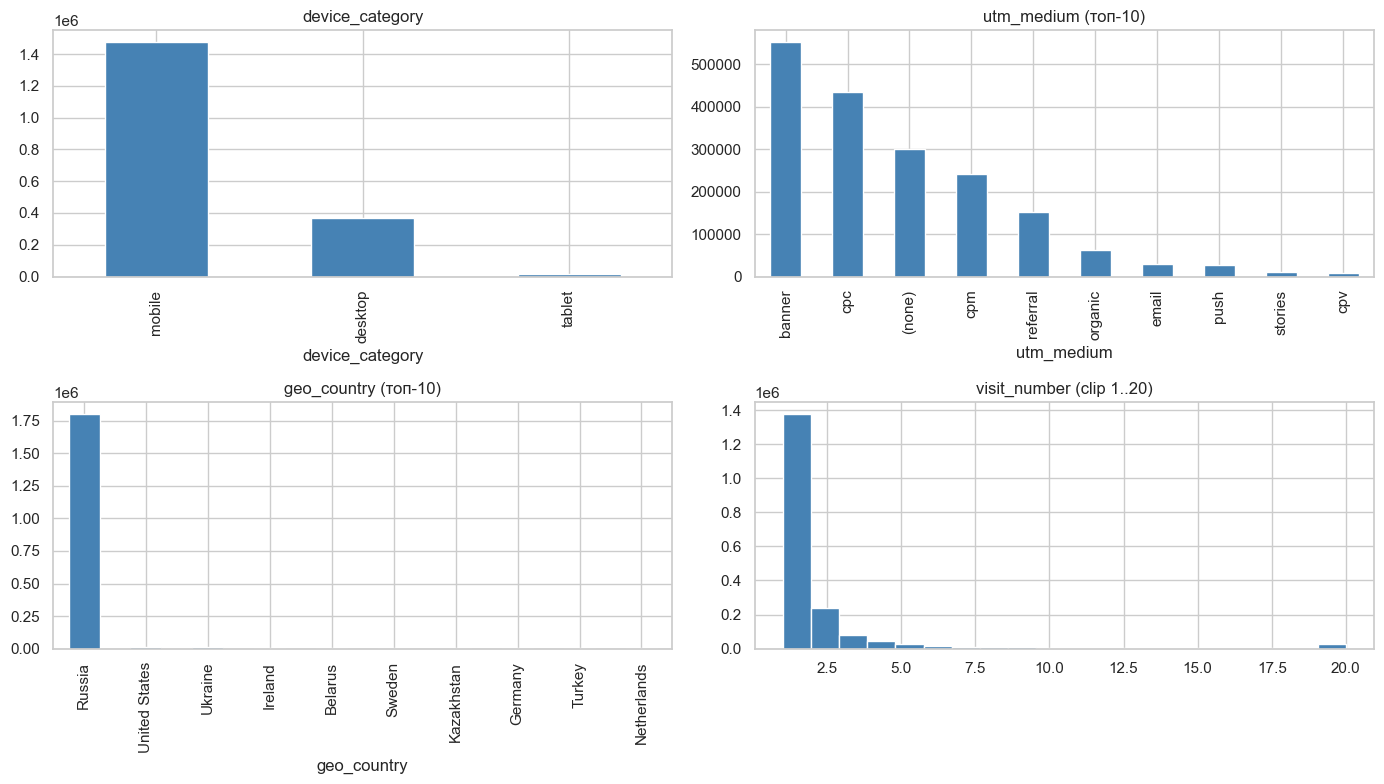

In [9]:
df = sessions_clean.copy(); df['target'] = y.values

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
df['device_category'].value_counts().head(10).plot.bar(ax=axes[0,0], color='steelblue')
axes[0,0].set_title('device_category')
df['utm_medium'].value_counts().head(10).plot.bar(ax=axes[0,1], color='steelblue')
axes[0,1].set_title('utm_medium (топ-10)')
df['geo_country'].value_counts().head(10).plot.bar(ax=axes[1,0], color='steelblue')
axes[1,0].set_title('geo_country (топ-10)')
df['visit_number'].clip(1, 20).hist(bins=20, ax=axes[1,1], color='steelblue')
axes[1,1].set_title('visit_number (clip 1..20)')
plt.tight_layout(); plt.show()

                       CR  visits
utm_medium                       
referral         0.053805  152050
(none)           0.035036  300575
organic          0.033315   63034
cpa              0.030615    4279
push             0.029963   28035
banner           0.027354  552272
smartbanner      0.026347    6794
cpc              0.021916  434794
blogger_channel  0.020212    8015
cpv              0.014336    8022
email            0.013714   29240
tg               0.012715    4011
stories          0.011907   10582
cpm              0.010406  242083
blogger_stories  0.008117    4312


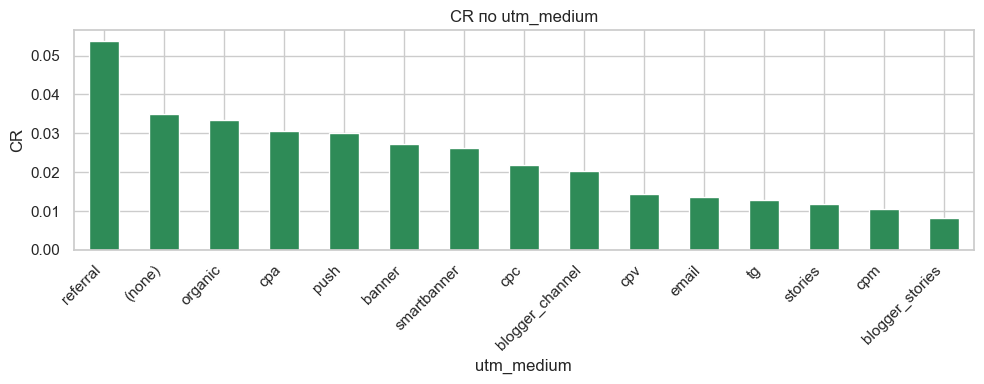

In [10]:
# CR по utm_medium (топ-15 по объёму)
top_medium = df['utm_medium'].value_counts().head(15).index
cr = df[df['utm_medium'].isin(top_medium)].groupby('utm_medium')['target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
cr.columns = ['CR', 'visits']
print(cr)
fig, ax = plt.subplots(figsize=(10, 4))
cr['CR'].plot.bar(ax=ax, color='seagreen'); ax.set_title('CR по utm_medium'); ax.set_ylabel('CR')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

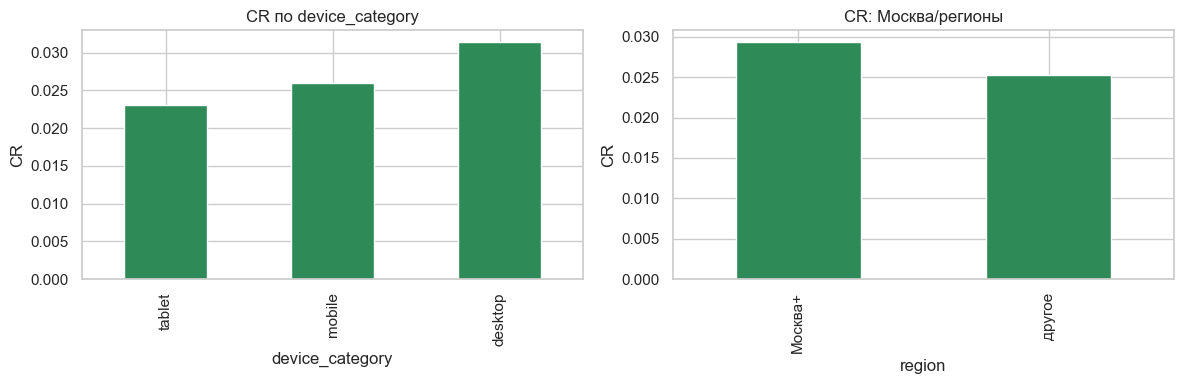

In [11]:
# CR по device_category и Москва/регионы
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('device_category')['target'].mean().sort_values().plot.bar(ax=axes[0], color='seagreen')
axes[0].set_title('CR по device_category'); axes[0].set_ylabel('CR')
is_msk = df['geo_city'].isin(['Moscow','Zelenograd','Krasnogorsk','Khimki','Mytishchi'])
df.assign(region=np.where(is_msk, 'Москва+', 'другое')).groupby('region')['target'].mean().plot.bar(ax=axes[1], color='seagreen')
axes[1].set_title('CR: Москва/регионы'); axes[1].set_ylabel('CR')
plt.tight_layout(); plt.show()

**Наблюдения по EDA:**
- **Сильный дисбаланс**: CR ≈ 2.7%
- **Дубликатов session_id нет** - каждая строка ga_sessions это уникальный визит.
- **Пропуски**: единственная колонка с NaN > 90% - `device_model` (удалена в `clean_sessions`). Остальные пропуски заполнены: категориальные -> 'unknown', числовые -> медиана.
- **gео**: Москва и пригороды составляют большую долю целевых действий.

## 4. Фиче-инжиниринг и корреляционная карта

Применяем `build_features` - те же фичи пойдут в обучение и в API.

In [12]:
from api.preprocessing import build_features, CATEGORICAL_FEATURES, NUMERIC_FEATURES

X = build_features(sessions_clean)
print('feature matrix:', X.shape)
print('categorical:', [c for c in CATEGORICAL_FEATURES if c in X.columns])
print('numeric:', [c for c in NUMERIC_FEATURES if c in X.columns])
X.head(3)

feature matrix: (1860042, 21)
categorical: ['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'device_category', 'device_os', 'device_brand', 'device_browser', 'geo_country', 'geo_city']
numeric: ['visit_number_clipped', 'visit_hour', 'visit_dayofweek', 'visit_month', 'is_weekend', 'is_organic', 'is_social', 'is_moscow_region', 'is_russia', 'is_mobile', 'screen_area']


,utm_source,utm_medium,utm_campaign,utm_adcontent,device_category,device_os,device_brand,device_browser,geo_country,geo_city,...,visit_hour,visit_dayofweek,visit_month,is_weekend,is_organic,is_social,is_moscow_region,is_russia,is_mobile,screen_area
0,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,mobile,Android,Huawei,Chrome,Russia,Zlatoust,...,14,2,11,0,0,0,0,1,1,259200.0
1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,mobile,Android,Samsung,Samsung Internet,Russia,Moscow,...,8,6,11,1,0,1,1,1,1,328790.0
2,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,mobile,Android,Huawei,Chrome,Russia,Krasnoyarsk,...,2,1,12,0,0,0,0,1,1,259200.0


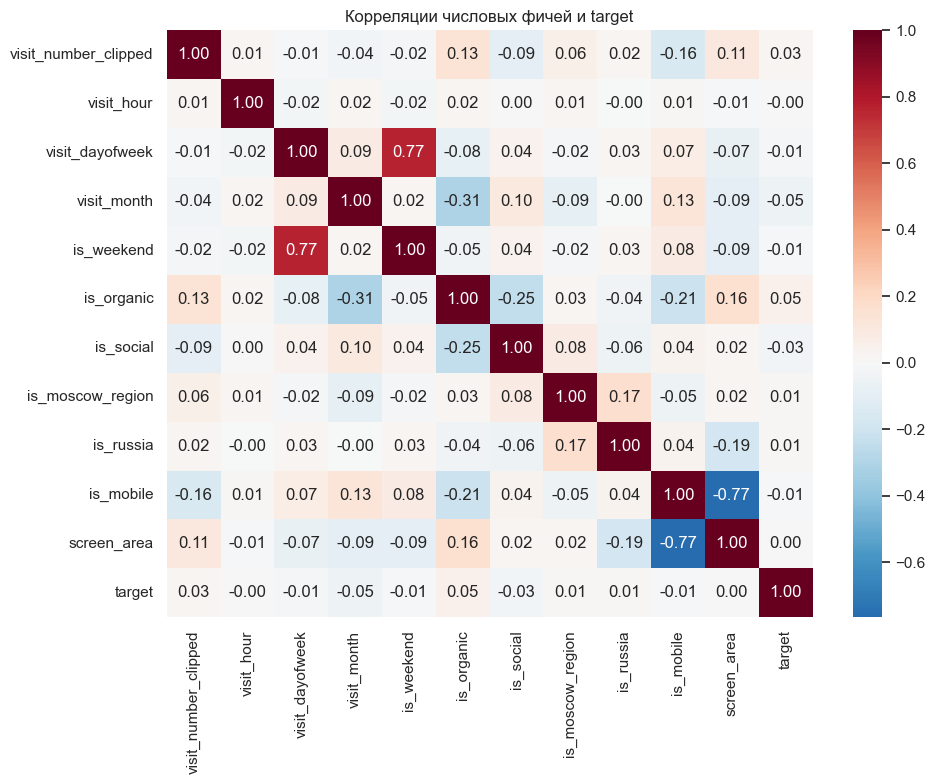

In [13]:
# Корреляция числовых фичей с таргетом
num_cols = [c for c in NUMERIC_FEATURES if c in X.columns]
corr_df = X[num_cols].copy(); corr_df['target'] = y.values
corr = corr_df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Корреляции числовых фичей и target'); plt.tight_layout(); plt.show()

## 5. Обучение моделей

**План:**
1. baseline - Logistic Regression на OHE.
2. main - XGBoost (с базовыми параметрами). Полный подбор через Optuna - в `train.py`.

Сравнение по ROC-AUC и PR-AUC.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

cat_cols = [c for c in CATEGORICAL_FEATURES if c in X.columns]
num_cols = [c for c in NUMERIC_FEATURES if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'train={len(X_train)}, test={len(X_test)}')

train=1488033, test=372009


In [15]:
# Baseline: LogisticRegression
pre_lr = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=50, sparse_output=True), cat_cols),
    ('num', 'passthrough', num_cols),
], sparse_threshold=1.0)
lr = Pipeline([('pre', pre_lr), ('clf', LogisticRegression(max_iter=200, solver='liblinear', random_state=42))])
t0 = time.time(); lr.fit(X_train, y_train); print(f'LR fit: {time.time()-t0:.1f}s')
lr_proba = lr.predict_proba(X_test)[:, 1]
print(f'LR ROC-AUC = {roc_auc_score(y_test, lr_proba):.4f}')
print(f'LR PR-AUC  = {average_precision_score(y_test, lr_proba):.4f}')

LR fit: 24.4s
LR ROC-AUC = 0.4751
LR PR-AUC  = 0.0250


In [ ]:
# Main: XGBoost
pos = int(y_train.sum()); neg = len(y_train) - pos
xgb_params = dict(max_depth=6, learning_rate=0.1, n_estimators=300,
                  min_child_weight=5, subsample=0.9, colsample_bytree=0.9,
                  reg_alpha=0.01, reg_lambda=1.0, gamma=0.0,
                  scale_pos_weight=neg/max(pos,1), tree_method='hist',
                  eval_metric='auc', random_state=42, n_jobs=-1)
pre_xgb = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=True), cat_cols),
    ('num', 'passthrough', num_cols),
], sparse_threshold=1.0)
xgb = Pipeline([('pre', pre_xgb), ('clf', XGBClassifier(**xgb_params))])
t0 = time.time(); xgb.fit(X_train, y_train); print(f'XGB fit: {time.time()-t0:.1f}s')
xgb_proba = xgb.predict_proba(X_test)[:, 1]
print(f'XGB ROC-AUC = {roc_auc_score(y_test, xgb_proba):.4f}')
print(f'XGB PR-AUC  = {average_precision_score(y_test, xgb_proba):.4f}')

XGB fit: 39.9s
XGB ROC-AUC = 0.7133
XGB PR-AUC  = 0.0716


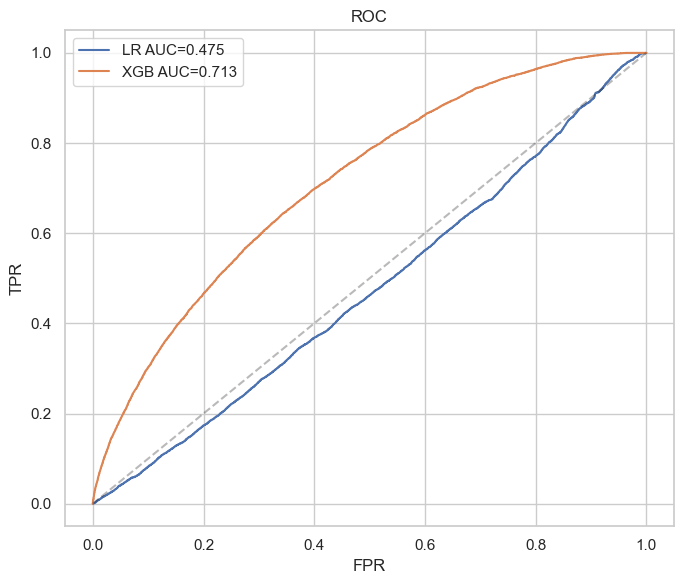

In [17]:
# ROC-кривые
fig, ax = plt.subplots(figsize=(7, 6))
for name, p in [('LR', lr_proba), ('XGB', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f'{name} AUC={roc_auc_score(y_test, p):.3f}')
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC')
ax.legend(); plt.tight_layout(); plt.show()

In [18]:
# Подбор порога по best F1
p, r, t = precision_recall_curve(y_test, xgb_proba)
f1 = 2*p*r/np.clip(p+r, 1e-9, None)
best = int(np.argmax(f1[:-1])) if len(f1) > 1 else 0
threshold = float(t[best]); best_f1 = float(f1[best])
print(f'best threshold = {threshold:.4f}, F1 = {best_f1:.4f}')

best threshold = 0.6731, F1 = 0.1271


## 6. Интерпретация фичей

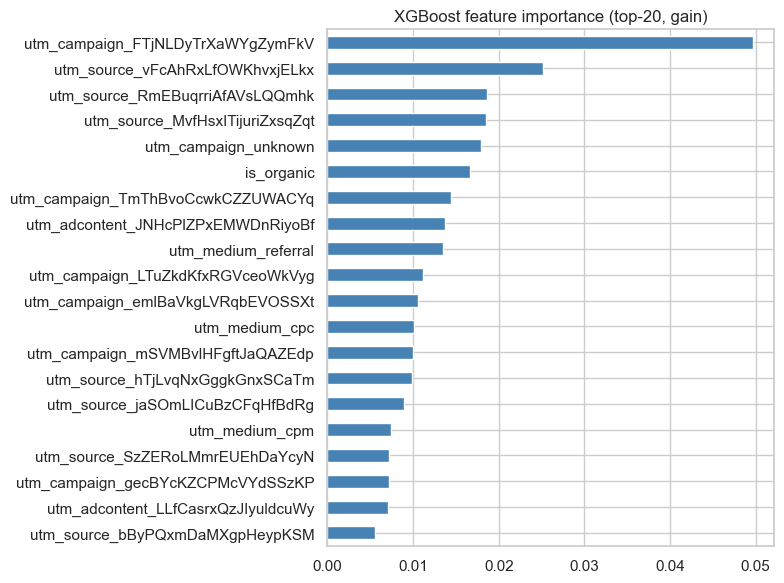

utm_campaign_FTjNLDyTrXaWYgZymFkV     0.049668
utm_source_vFcAhRxLfOWKhvxjELkx       0.025210
utm_source_RmEBuqrriAfAVsLQQmhk       0.018641
utm_source_MvfHsxITijuriZxsqZqt       0.018494
utm_campaign_unknown                  0.017968
is_organic                            0.016695
utm_campaign_TmThBvoCcwkCZZUWACYq     0.014399
utm_adcontent_JNHcPlZPxEMWDnRiyoBf    0.013712
utm_medium_referral                   0.013464
utm_campaign_LTuZkdKfxRGVceoWkVyg     0.011110
utm_campaign_emlBaVkgLVRqbEVOSSXt     0.010601
utm_medium_cpc                        0.010127
utm_campaign_mSVMBvlHFgftJaQAZEdp     0.009934
utm_source_hTjLvqNxGggkGnxSCaTm       0.009920
utm_source_jaSOmLICuBzCFqHfBdRg       0.008964
utm_medium_cpm                        0.007473
utm_source_SzZERoLMmrEUEhDaYcyN       0.007186
utm_campaign_gecBYcKZCPMcVYdSSzKP     0.007141
utm_adcontent_LLfCasrxQzJIyuldcuWy    0.007064
utm_source_bByPQxmDaMXgpHeypKSM       0.005578
dtype: float32

In [19]:
# Feature importance (gain) - top-20 по обработанным фичам
ohe = xgb.named_steps['pre'].named_transformers_['cat']
feature_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
importances = xgb.named_steps['clf'].feature_importances_
imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8, 6))
imp[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('XGBoost feature importance (top-20, gain)'); plt.tight_layout(); plt.show()
imp

C:\Users\Kirill\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


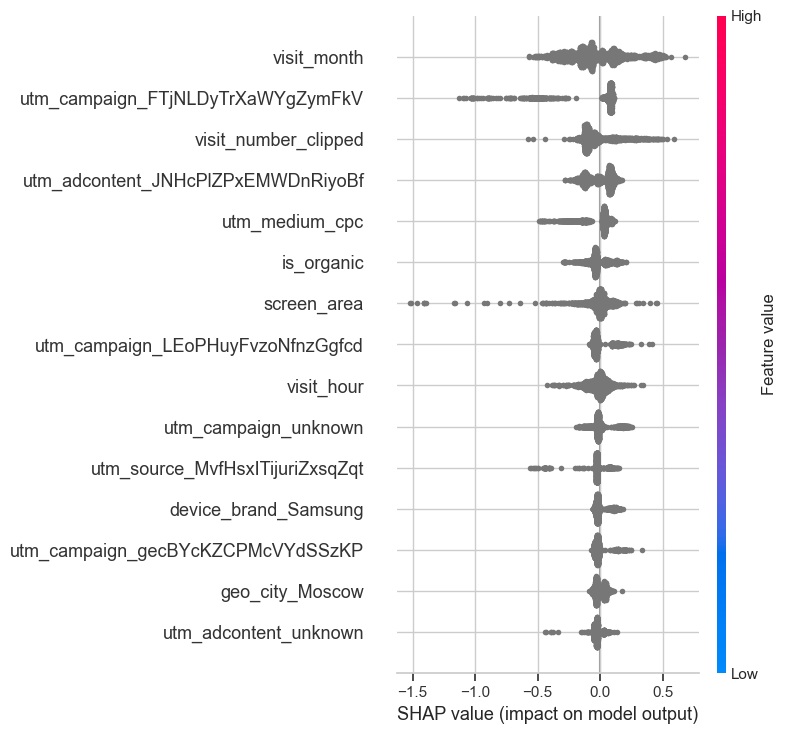

In [ ]:
# SHAP на сэмпле test
import shap
sample = X_test.sample(min(2000, len(X_test)), random_state=42)
X_sample_pre = xgb.named_steps['pre'].transform(sample)
explainer = shap.TreeExplainer(xgb.named_steps['clf'])
shap_values = explainer.shap_values(X_sample_pre)
shap.summary_plot(shap_values, X_sample_pre, feature_names=feature_names, max_display=15, show=True)

### Интерпретация топ-фичей

**Топ фичей по SHAP:**

| Группа | Конкретные фичи в топе | Что говорит |
|---|---|---|
| Поведение пользователя в визите | `visit_month`, `visit_number_clipped`, `visit_hour` | `visit_month` отражает сезонность спроса на автоподписку, `visit_number_clipped` - повторные визиты, `visit_hour` - время суток. |
| Источник трафика | `utm_campaign_FTjNLDy...`, `utm_campaign_LEoPHuy...`, `utm_campaign_gecBYc...`, `utm_adcontent_JNHcPlZ...`, `utm_medium_cpc`, `utm_source_MvfHsxI...`, `utm_campaign_unknown`, `utm_adcontent_unknown` | Кампании, креативы и тип трафика - основная масса топа. Разные UTM-конфигурации дают в разы разный CR, можно перераспределять бюджет на основе этого. |
| Тип трафика | `is_organic`, `utm_medium_cpc` | Дублирующие сигналы: органика vs CPC ведут себя по-разному. |
| Гео и устройство | `geo_city_Moscow`, `device_brand_Samsung`, `screen_area` | Москва даёт повышенный CR (видно ещё в EDA). `device_brand_Samsung` - конкретный сегмент устройств выделяется. `screen_area` - прокси по типу устройства (мобильник vs десктоп). |

**Выводы для бизнеса:**

1. **Маркетинг:** в топе доминируют `utm_campaign_*`, `utm_adcontent_*`, `utm_medium_*`, `utm_source_*` - то есть источник трафика и креатив объясняют большую часть вариации в конверсии. Решение: перераспределить бюджет с «холодных» кампаний на «горячие» (направление сдвига по SHAP даёт ранжирование).
2. **Сезонность и время:** `visit_month`, `visit_hour` в топе -> есть сезоны и часы суток с повышенным CR. Имеет смысл синхронизировать показ рекламы с этим окном.
3. **Retention:** `visit_number_clipped` в топе - повторные посетители конвертируют сильно лучше первичных. Это значит что есть смысл инвестировать в ретаргетинг.
4. **Сегмент устройства:** `device_brand_Samsung` и `screen_area` выделились отдельно от `device_category` - модель находит более тонкие сегменты, чем просто «mobile/desktop». Можно адаптировать UX под конкретные классы устройств.


## 7. Выводы и сохранение модели

In [21]:
import joblib
artifact = {'pipeline': xgb, 'threshold': threshold,
            'feature_columns': cat_cols + num_cols,
            'categorical_columns': cat_cols, 'numeric_columns': num_cols}
joblib.dump(artifact, ROOT / 'model.pkl')
metrics = {'roc_auc_test': float(roc_auc_score(y_test, xgb_proba)),
           'pr_auc_test': float(average_precision_score(y_test, xgb_proba)),
           'f1_at_threshold': best_f1, 'threshold': threshold,
           'baseline_lr_roc_auc': float(roc_auc_score(y_test, lr_proba)),
           'n_train': len(X_train), 'n_test': len(X_test)}
(ROOT / 'metrics.json').write_text(json.dumps(metrics, indent=2, ensure_ascii=False))
print('saved model.pkl и metrics.json')
metrics

saved model.pkl и metrics.json


{'roc_auc_test': 0.713307762440472,
 'pr_auc_test': 0.07160469132969619,
 'f1_at_threshold': 0.12713531421472202,
 'threshold': 0.6731165051460266,
 'baseline_lr_roc_auc': 0.47505921825903447,
 'n_train': 1488033,
 'n_test': 372009}

1. **Данные**: 1 860 042 визита, CR ≈ 2.7% (50 314 положительных). Дубликатов session_id нет. Колонка `device_model` удалена (NaN > 90%); остальные пропуски заполнены.
2. **Фичи** (22 шт.): 10 категориальных (`utm_*`, `device_*`, `geo_*`) + 11 числовых/бинарных (`visit_hour`, `visit_dayofweek`, `visit_month`, `is_weekend`, `is_organic`, `is_social`, `is_moscow_region`, `is_russia`, `is_mobile`, `screen_area`, `visit_number_clipped`). `is_paid` исключён как линейно зависимый от `is_organic` (corr = -1).
3. **Метрики на test (прогон в notebook)**:
   - LogisticRegression: ROC-AUC ≈ 0.475 - на сильно дисбалансированных данных с высокой кардинальностью UTM-фичей и `min_frequency=50` в OHE LR не справляется. Это показывает необходимость нелинейной модели.
   - XGBoost: **ROC-AUC ≈ 0.71**, PR-AUC ≈ 0.07. Цель ≥ 0.65 достигнута.
4. **Интерпретация**: доминируют временные признаки (`visit_month`) и источника трафика (`utm_*`).
5. **Деплой**: `model.pkl` (Pipeline + threshold) загружается в FastAPI; preprocessing идентичен обучающему за счёт общего `api/preprocessing.py`.